# Layout transform overhead analysis

Analyze `base_t32-llama2_7b_layout_fused_seq_sweep/raw_db.csv` and `base_t8-llama2_7b_layout_fused_seq_sweep/raw_db.csv`, then compare baseline kernels against layout-fused kernels for the same `(fpga, op, batch, seq, M, K)` shape.

- Baseline: `rmsnorm`, `silu`
- Layout fused: `rms_norm_layout_fused`, `silu_layout_fused`
- Main metric: `avg_us`
- Overhead: `fused_avg_us - baseline_avg_us`, and `fused_avg_us / baseline_avg_us - 1`


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

DATASETS = {
    'base_t32': Path('/home/jaeyongjang/project.local/vortex/build/results/latency/base_t32-llama2_7b_layout_fused_seq_sweep/raw_db.csv'),
    'base_t8': Path('/home/jaeyongjang/project.local/vortex/build/results/latency/base_t8-llama2_7b_layout_fused_seq_sweep/raw_db.csv'),
}

def normalize_op(kind: str) -> str:
    if 'rms' in kind:
        return 'rmsnorm'
    if 'silu' in kind:
        return 'silu'
    return kind

def load_dataset(fpga: str, path: Path) -> pd.DataFrame:
    out = pd.read_csv(path)
    shape = out['shape_json'].apply(json.loads).apply(pd.Series)
    out = pd.concat([out, shape], axis=1)
    out['fpga'] = fpga
    out['op'] = out['kind'].map(normalize_op)
    out['variant_norm'] = out['kind'].map(lambda k: 'layout_fused' if 'layout_fused' in k else 'baseline')
    return out

df = pd.concat([load_dataset(fpga, path) for fpga, path in DATASETS.items()], ignore_index=True)

print(df.shape)
df[['fpga', 'case_id', 'kind', 'op', 'variant_norm', 'batch', 'seq', 'M', 'K', 'avg_us']].head()

(64, 40)


,fpga,case_id,kind,op,variant_norm,batch,seq,M,K,avg_us
0,base_t32,rmsnorm_b1_s1,rmsnorm,rmsnorm,baseline,1.0,1.0,1.0,4096.0,2683.357
1,base_t32,rmsnorm_b1_s128,rmsnorm,rmsnorm,baseline,1.0,128.0,128.0,4096.0,49190.999
2,base_t32,rmsnorm_b1_s512,rmsnorm,rmsnorm,baseline,1.0,512.0,512.0,4096.0,189923.123
3,base_t32,rmsnorm_b1_s1024,rmsnorm,rmsnorm,baseline,1.0,1024.0,1024.0,4096.0,378697.647
4,base_t32,rmsnorm_b8_s1,rmsnorm,rmsnorm,baseline,8.0,1.0,8.0,4096.0,4801.821


In [2]:
keys = ['fpga', 'op', 'batch', 'seq', 'M', 'K']
metrics = ['avg_us', 'min_us', 'p50_us', 'p95_us', 'case_id']

base = (
    df[df['variant_norm'] == 'baseline'][keys + metrics]
    .rename(columns={c: f'baseline_{c}' for c in metrics})
)
fused = (
    df[df['variant_norm'] == 'layout_fused'][keys + metrics]
    .rename(columns={c: f'fused_{c}' for c in metrics})
)

paired = base.merge(fused, on=keys, how='inner')
paired['baseline_ms'] = paired['baseline_avg_us'] / 1000
paired['fused_ms'] = paired['fused_avg_us'] / 1000
paired['overhead_us'] = paired['fused_avg_us'] - paired['baseline_avg_us']
paired['overhead_ms'] = paired['overhead_us'] / 1000
paired['overhead_pct'] = paired['overhead_us'] / paired['baseline_avg_us'] * 100
paired['ratio'] = paired['fused_avg_us'] / paired['baseline_avg_us']
paired = paired.sort_values(['fpga', 'op', 'batch', 'seq']).reset_index(drop=True)

display_cols = ['fpga', 'op', 'batch', 'seq', 'M', 'K', 'baseline_ms', 'fused_ms', 'overhead_ms', 'overhead_pct', 'ratio']
paired[display_cols]

,fpga,op,batch,seq,M,K,baseline_ms,fused_ms,overhead_ms,overhead_pct,ratio
0,base_t32,rmsnorm,1.0,1.0,1.0,4096.0,2.683357,2.669540,-0.013817,-0.514915,0.994851
1,base_t32,rmsnorm,1.0,128.0,128.0,4096.0,49.190999,53.458157,4.267158,8.674672,1.086747
2,base_t32,rmsnorm,1.0,512.0,512.0,4096.0,189.923123,210.107769,20.184646,10.627798,1.106278
3,base_t32,rmsnorm,1.0,1024.0,1024.0,4096.0,378.697647,417.350614,38.652967,10.206815,1.102068
4,base_t32,rmsnorm,8.0,1.0,8.0,4096.0,4.801821,4.785666,-0.016155,-0.336435,0.996636
5,base_t32,rmsnorm,8.0,128.0,1024.0,4096.0,378.227283,417.350614,39.123331,10.343868,1.103439
6,base_t32,rmsnorm,8.0,512.0,4096.0,4096.0,1508.357139,1665.888258,157.531119,10.443887,1.104439
7,base_t32,rmsnorm,8.0,1024.0,8192.0,4096.0,3014.073441,3330.275405,316.201964,10.490851,1.104909
8,base_t32,silu,1.0,1.0,1.0,11008.0,2.671057,5.834075,3.163018,118.418214,2.184182
9,base_t32,silu,1.0,128.0,128.0,11008.0,74.105213,562.806322,488.701109,659.469272,7.594693


In [3]:
summary_by_op = (
    paired.groupby(['fpga', 'op'])
    .agg(
        n=('overhead_pct', 'size'),
        mean_overhead_pct=('overhead_pct', 'mean'),
        median_overhead_pct=('overhead_pct', 'median'),
        min_overhead_pct=('overhead_pct', 'min'),
        max_overhead_pct=('overhead_pct', 'max'),
        mean_overhead_ms=('overhead_ms', 'mean'),
        total_baseline_ms=('baseline_ms', 'sum'),
        total_fused_ms=('fused_ms', 'sum'),
    )
    .reset_index()
)
summary_by_op['aggregate_overhead_pct'] = (
    (summary_by_op['total_fused_ms'] - summary_by_op['total_baseline_ms'])
    / summary_by_op['total_baseline_ms'] * 100
)
summary_by_op

,fpga,op,n,mean_overhead_pct,median_overhead_pct,min_overhead_pct,max_overhead_pct,mean_overhead_ms,total_baseline_ms,total_fused_ms,aggregate_overhead_pct
0,base_t32,rmsnorm,8,7.492068,10.275341,-0.514915,10.627798,71.991402,5525.954810,6101.886023,10.422293
1,base_t32,silu,8,571.611269,669.588049,118.418214,679.727629,7173.850202,8484.834612,65875.636224,676.392696
2,base_t8,rmsnorm,8,28.041424,30.000120,0.611622,43.834862,271.973499,7247.804297,9423.592285,30.019961
3,base_t8,silu,8,257.963128,266.445686,178.044533,286.104560,11286.708465,33874.569538,124168.237254,266.552960


In [4]:
summary_by_op_batch = (
    paired.groupby(['fpga', 'op', 'batch'])
    .agg(
        n=('overhead_pct', 'size'),
        mean_overhead_pct=('overhead_pct', 'mean'),
        median_overhead_pct=('overhead_pct', 'median'),
        min_overhead_pct=('overhead_pct', 'min'),
        max_overhead_pct=('overhead_pct', 'max'),
        total_baseline_ms=('baseline_ms', 'sum'),
        total_fused_ms=('fused_ms', 'sum'),
    )
    .reset_index()
)
summary_by_op_batch['aggregate_overhead_pct'] = (
    (summary_by_op_batch['total_fused_ms'] - summary_by_op_batch['total_baseline_ms'])
    / summary_by_op_batch['total_baseline_ms'] * 100
)
summary_by_op_batch

,fpga,op,batch,n,mean_overhead_pct,median_overhead_pct,min_overhead_pct,max_overhead_pct,total_baseline_ms,total_fused_ms,aggregate_overhead_pct
0,base_t32,rmsnorm,1.0,4,7.248593,9.440744,-0.514915,10.627798,620.495126,683.586080,10.167840
1,base_t32,rmsnorm,8.0,4,7.735543,10.393878,-0.336435,10.490851,4905.459684,5418.299943,10.454479
2,base_t32,silu,1.0,4,529.265896,663.922116,118.418214,670.801139,951.139442,7301.158970,667.622354
3,base_t32,silu,8.0,4,613.956641,673.144049,429.810839,679.727629,7533.695170,58574.477254,677.499964
4,base_t8,rmsnorm,1.0,4,22.608636,29.913519,0.611622,29.995887,809.260040,1051.142655,29.889356
5,base_t8,rmsnorm,8.0,4,33.474212,30.028816,30.004353,43.834862,6438.544257,8372.449630,30.036376
6,base_t8,silu,1.0,4,244.886297,266.106144,178.044533,269.288368,3785.801774,13853.935458,265.944555
7,base_t8,silu,8.0,4,271.039959,266.497790,265.059695,286.104560,30088.767764,110314.301796,266.629510


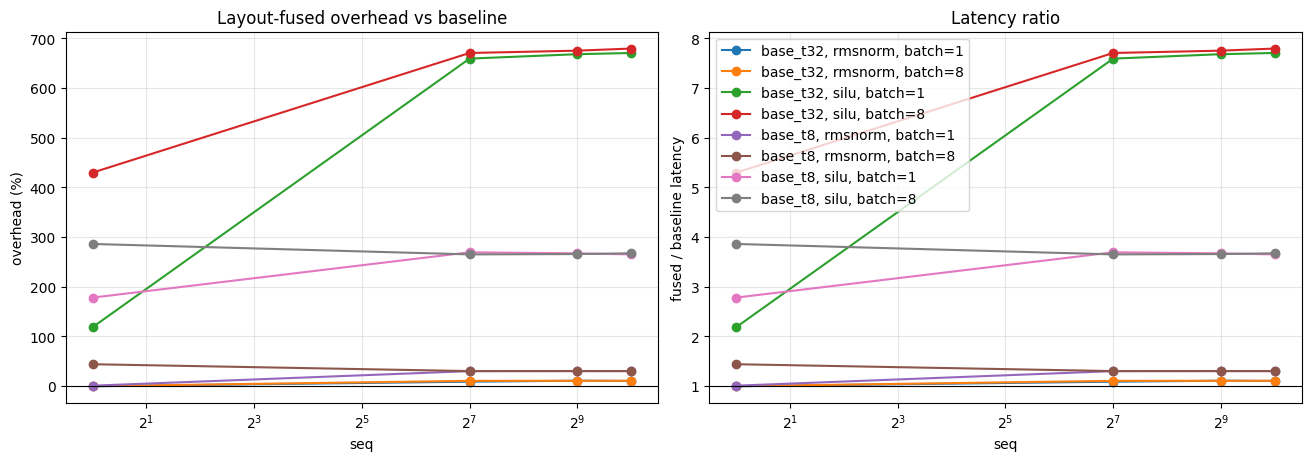

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for (fpga, op, batch), g in paired.groupby(['fpga', 'op', 'batch']):
    label = f'{fpga}, {op}, batch={int(batch)}'
    axes[0].plot(g['seq'], g['overhead_pct'], marker='o', label=label)
    axes[1].plot(g['seq'], g['ratio'], marker='o', label=label)

axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xscale('log', base=2)
axes[0].set_xlabel('seq')
axes[0].set_ylabel('overhead (%)')
axes[0].set_title('Layout-fused overhead vs baseline')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1, color='black', linewidth=0.8)
axes[1].set_xscale('log', base=2)
axes[1].set_xlabel('seq')
axes[1].set_ylabel('fused / baseline latency')
axes[1].set_title('Latency ratio')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.show()

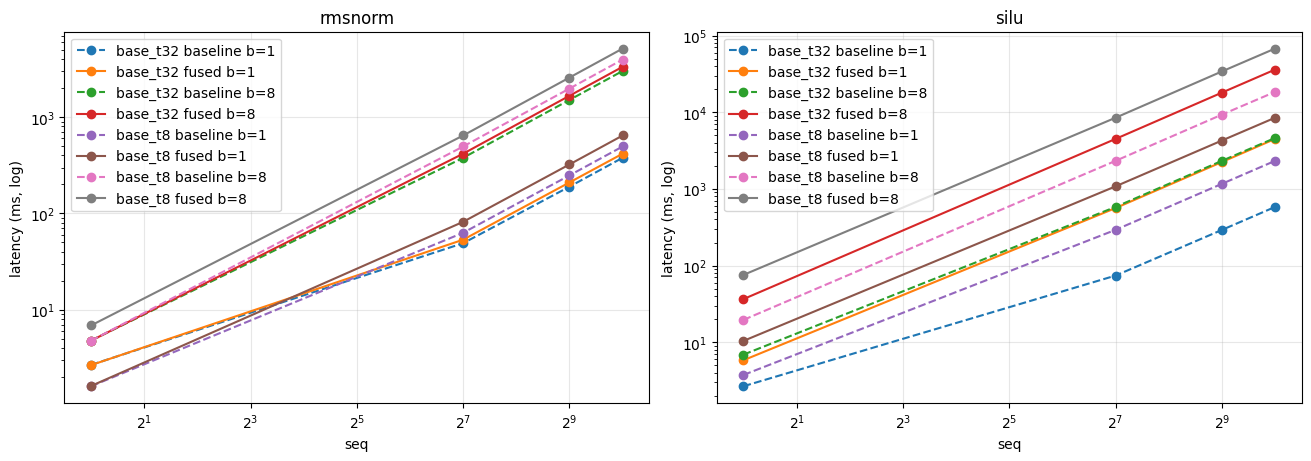

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for op, ax in zip(['rmsnorm', 'silu'], axes):
    gop = paired[paired['op'] == op]
    for (fpga, batch), g in gop.groupby(['fpga', 'batch']):
        ax.plot(g['seq'], g['baseline_ms'], marker='o', linestyle='--', label=f'{fpga} baseline b={int(batch)}')
        ax.plot(g['seq'], g['fused_ms'], marker='o', label=f'{fpga} fused b={int(batch)}')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('seq')
    ax.set_ylabel('latency (ms, log)')
    ax.set_title(op)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.show()

## Cross-FPGA overhead comparison

Compare overhead percentages between `base_t32` and `base_t8` for the same operation and shape.

In [7]:
comparison = paired.pivot_table(
    index=['op', 'batch', 'seq', 'M', 'K'],
    columns='fpga',
    values=['baseline_ms', 'fused_ms', 'overhead_pct', 'ratio'],
    aggfunc='first',
)
comparison.columns = [f'{metric}_{fpga}' for metric, fpga in comparison.columns]
comparison = comparison.reset_index()
comparison['t8_minus_t32_overhead_pct_pt'] = (
    comparison['overhead_pct_base_t8'] - comparison['overhead_pct_base_t32']
)
comparison[
    [
        'op', 'batch', 'seq',
        'overhead_pct_base_t32', 'overhead_pct_base_t8', 't8_minus_t32_overhead_pct_pt',
        'ratio_base_t32', 'ratio_base_t8',
    ]
]

,op,batch,seq,overhead_pct_base_t32,overhead_pct_base_t8,t8_minus_t32_overhead_pct_pt,ratio_base_t32,ratio_base_t8
0,rmsnorm,1.0,1.0,-0.514915,0.611622,1.126536,0.994851,1.006116
1,rmsnorm,1.0,128.0,8.674672,29.896861,21.222189,1.086747,1.298969
2,rmsnorm,1.0,512.0,10.627798,29.995887,19.368089,1.106278,1.299959
3,rmsnorm,1.0,1024.0,10.206815,29.930176,19.723362,1.102068,1.299302
4,rmsnorm,8.0,1.0,-0.336435,43.834862,44.171296,0.996636,1.438349
5,rmsnorm,8.0,128.0,10.343868,30.004353,19.660485,1.103439,1.300044
6,rmsnorm,8.0,512.0,10.443887,30.031498,19.587611,1.104439,1.300315
7,rmsnorm,8.0,1024.0,10.490851,30.026134,19.535283,1.104909,1.300261
8,silu,1.0,1.0,118.418214,178.044533,59.626319,2.184182,2.780445
9,silu,1.0,128.0,659.469272,269.288368,-390.180905,7.594693,3.692884


## Current run observations

- `base_t32 rmsnorm`: layout-fused latency is almost identical at `seq=1`, then stabilizes around **+10% overhead** for larger sequences. Aggregate overhead across all paired shapes is about **+10.4%**.
- `base_t8 rmsnorm`: layout-fused overhead is much larger than `base_t32`, stabilizing around **+30%** for non-trivial sequences. Aggregate overhead is about **+30.0%**.
- `base_t32 silu`: layout-fused is much slower. For non-trivial sequences it is about **7.6x-7.8x** baseline latency, or roughly **+660% to +680% overhead**. Aggregate overhead is about **+676%**.
- `base_t8 silu`: layout-fused is still much slower than baseline, but less extreme than `base_t32`: about **3.65x-3.69x** for non-trivial sequences. Aggregate overhead is about **+266.6%**.
- The `batch=1, seq=1024` and `batch=8, seq=128` points share the same `M=1024`, so identical fused command arguments produce identical latency rows. This is expected for kernels keyed by flattened `M=batch*seq`.
- Interpretation: `rmsnorm` layout-fused overhead is sensitive to the TCU shape (`t8` pays about 20 percentage points more overhead than `t32` for large shapes). `silu_layout_fused` remains dominated by fused/layout work on both bins, but the relative slowdown is smaller on `t8` because the baseline `silu` path is also substantially slower there.